## 1. Load the Dataset

We load the CSV file using pandas to begin our analysis.


In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv('../data/raw/studentAssessment.csv')
print('Dataset loaded successfully')

Dataset loaded successfully


## 2. Dataset Shape and Column Names

Understanding the dimensions of the dataset helps us know how many rows (samples) and columns (features) we have.


In [22]:
print(f'Dataset shape: {df.shape}')
print(f'\nNumber of rows: {df.shape[0]}')
print(f'Number of columns: {df.shape[1]}')
print(f'\nColumn names:')
print(df.columns.tolist())

Dataset shape: (173912, 5)

Number of rows: 173912
Number of columns: 5

Column names:
['id_assessment', 'id_student', 'date_submitted', 'is_banked', 'score']


## 3. Preview First and Last Rows

Examining the first and last rows gives us a sense of the data content and structure.


In [23]:
print('First 5 rows:')
print(df.head())
print('\n' + '='*80 + '\n')
print('Last 5 rows:')
print(df.tail())

First 5 rows:
   id_assessment  id_student  date_submitted  is_banked  score
0           1752       11391              18          0   78.0
1           1752       28400              22          0   70.0
2           1752       31604              17          0   72.0
3           1752       32885              26          0   69.0
4           1752       38053              19          0   79.0


Last 5 rows:
        id_assessment  id_student  date_submitted  is_banked  score
173907          37443      527538             227          0   60.0
173908          37443      534672             229          0  100.0
173909          37443      546286             215          0   80.0
173910          37443      546724             230          0  100.0
173911          37443      558486             224          0   80.0


## 4. Data Types

Knowing the data type of each column is crucial for determining appropriate analysis and preprocessing techniques.


In [24]:
print('Data types:')
print(df.dtypes)
print('\n' + '='*80 + '\n')
print('Data type summary:')
print(df.dtypes.value_counts())

Data types:
id_assessment       int64
id_student          int64
date_submitted      int64
is_banked           int64
score             float64
dtype: object


Data type summary:
int64      4
float64    1
Name: count, dtype: int64


## 5. Missing Value Analysis

Identifying missing values helps us understand data quality and determine handling strategies. We check both count and percentage of missing values.


In [25]:
missing_data = pd.DataFrame({
    'Missing_Count': df.isnull().sum(),
    'Missing_Percentage': (df.isnull().sum() / len(df)) * 100
})

missing_data = missing_data[missing_data['Missing_Count'] > 0].sort_values('Missing_Count', ascending=False)

if len(missing_data) == 0:
    print('No missing values found in the dataset.')
else:
    print('Missing values:')
    print(missing_data)

Missing values:
       Missing_Count  Missing_Percentage
score            173            0.099476


## 6. Duplicate Row Check

Duplicates can distort our analysis. We check for completely identical rows and rows with duplicate key identifiers.


In [26]:
# Check for completely duplicate rows
total_duplicates = df.duplicated().sum()
print(f'Total completely duplicate rows: {total_duplicates}')
print(f'Percentage of duplicates: {(total_duplicates / len(df)) * 100:.2f}%')

# Check for duplicates in each column
print('\nDuplicate counts per column:')
for col in df.columns:
    dup_count = df[col].duplicated().sum()
    if dup_count > 0:
        print(f'{col}: {dup_count} duplicates ({(dup_count/len(df))*100:.2f}%)')

Total completely duplicate rows: 0
Percentage of duplicates: 0.00%

Duplicate counts per column:
id_assessment: 173724 duplicates (99.89%)
id_student: 150543 duplicates (86.56%)
date_submitted: 173600 duplicates (99.82%)
is_banked: 173910 duplicates (100.00%)
score: 173810 duplicates (99.94%)


## 7. Summary Statistics for Numeric Columns

Descriptive statistics provide insights into the distribution, central tendency, and spread of numeric features.


In [27]:
print('Summary statistics for numeric columns:')
print(df.describe())

Summary statistics for numeric columns:
       id_assessment    id_student  date_submitted      is_banked  \
count  173912.000000  1.739120e+05   173912.000000  173912.000000   
mean    26553.803556  7.051507e+05      116.032942       0.010977   
std      8829.784254  5.523952e+05       71.484148       0.104194   
min      1752.000000  6.516000e+03      -11.000000       0.000000   
25%     15022.000000  5.044290e+05       51.000000       0.000000   
50%     25359.000000  5.852080e+05      116.000000       0.000000   
75%     34883.000000  6.344980e+05      173.000000       0.000000   
max     37443.000000  2.698588e+06      608.000000       1.000000   

               score  
count  173739.000000  
mean       75.799573  
std        18.798107  
min         0.000000  
25%        65.000000  
50%        80.000000  
75%        90.000000  
max       100.000000  


## 8. Assessment Score and Submission Analysis

Analyze submission timing, score distributions, and student performance across assessments.


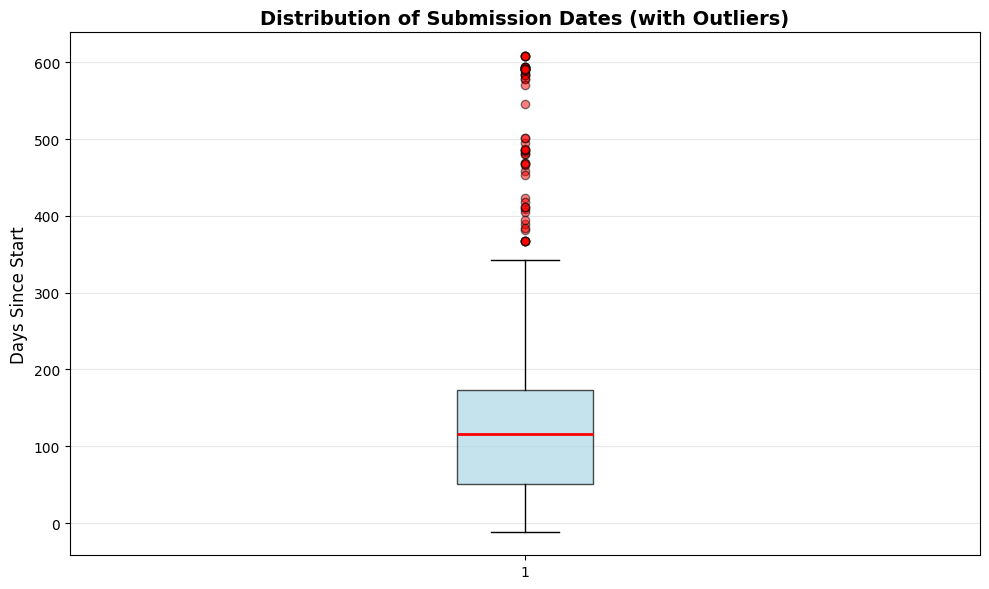

Date Submitted Statistics:
count    173912.000000
mean        116.032942
std          71.484148
min         -11.000000
25%          51.000000
50%         116.000000
75%         173.000000
max         608.000000
Name: date_submitted, dtype: float64


In [28]:
# 10.1: Boxplot for date_submitted
fig, ax = plt.subplots(figsize=(10, 6))
ax.boxplot(df['date_submitted'].dropna(), vert=True, patch_artist=True,
           boxprops=dict(facecolor='lightblue', alpha=0.7),
           medianprops=dict(color='red', linewidth=2),
           whiskerprops=dict(color='black'),
           capprops=dict(color='black'),
           flierprops=dict(marker='o', markerfacecolor='red', markersize=6, alpha=0.5))
ax.set_title('Distribution of Submission Dates (with Outliers)', fontsize=14, fontweight='bold')
ax.set_ylabel('Days Since Start', fontsize=12)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print('Date Submitted Statistics:')
print(df['date_submitted'].describe())

## 9. Score Distribution and Performance Analysis

Examine score distributions and student performance metrics across assessments.


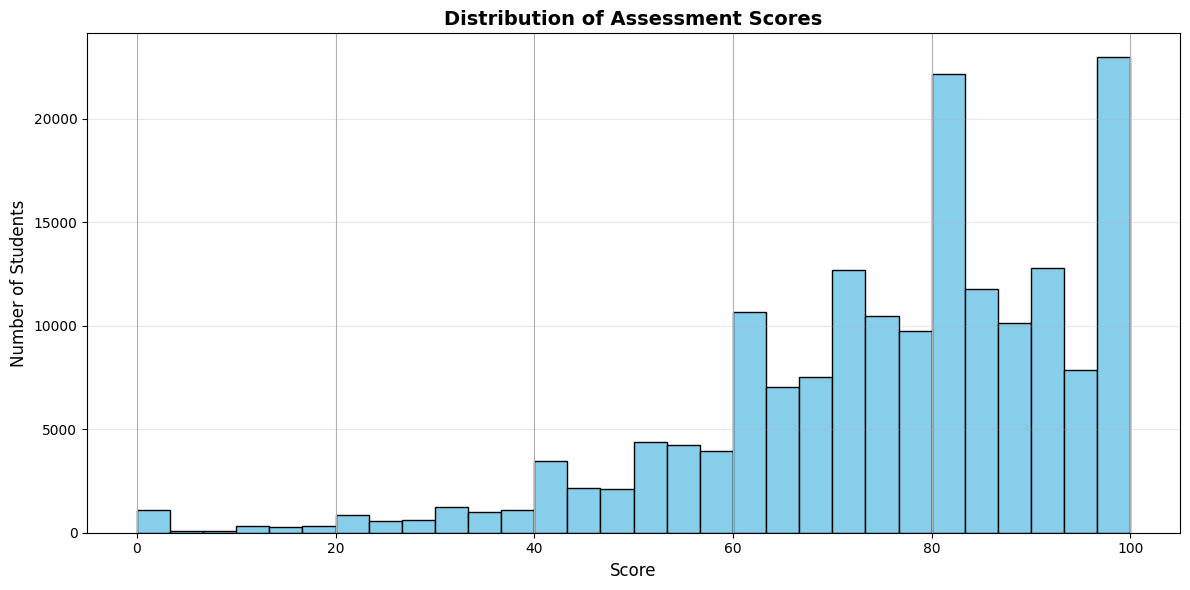

Score Statistics:
count    173739.000000
mean         75.799573
std          18.798107
min           0.000000
25%          65.000000
50%          80.000000
75%          90.000000
max         100.000000
Name: score, dtype: float64




In [29]:
# 9.1: Histogram for Score vs number of students
fig, ax = plt.subplots(figsize=(12, 6))
df['score'].dropna().hist(bins=30, color='skyblue', edgecolor='black', ax=ax)
ax.set_title('Distribution of Assessment Scores', fontsize=14, fontweight='bold')
ax.set_xlabel('Score', fontsize=12)
ax.set_ylabel('Number of Students', fontsize=12)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print('Score Statistics:')
print(df['score'].describe())

print('\n' + '='*80 + '\n')


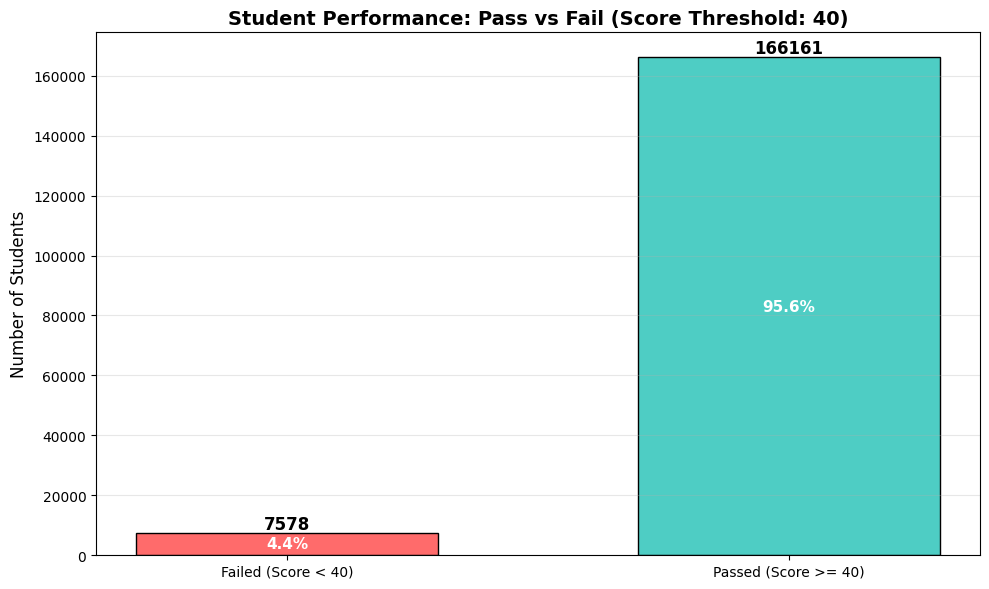

Student Performance Summary (records with scores only):
Failed (Score < 40)       7578
Passed (Score >= 40)    166161
dtype: int64

Percentage Distribution:
Failed (Score < 40)      4.36
Passed (Score >= 40)    95.64
dtype: float64


In [30]:
# 9.2: Barplot of pass/fail (score < 40 is fail)
df_with_scores = df[df['score'].notna()].copy()
pass_fail_status = pd.Series({
    'Failed (Score < 40)': (df_with_scores['score'] < 40).sum(),
    'Passed (Score >= 40)': (df_with_scores['score'] >= 40).sum()
})

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#ff6b6b', '#4ecdc4']
ax.bar(pass_fail_status.index, pass_fail_status.values, color=colors, edgecolor='black', width=0.6)
ax.set_title('Student Performance: Pass vs Fail (Score Threshold: 40)', fontsize=14, fontweight='bold')
ax.set_ylabel('Number of Students', fontsize=12)
ax.grid(axis='y', alpha=0.3)

# Add value labels on bars
for i, v in enumerate(pass_fail_status.values):
    ax.text(i, v + 20, str(v), ha='center', va='bottom', fontsize=12, fontweight='bold')
    percentage = (v / pass_fail_status.sum()) * 100
    ax.text(i, v/2, f'{percentage:.1f}%', ha='center', va='center', fontsize=11, fontweight='bold', color='white')

plt.tight_layout()
plt.show()

print('Student Performance Summary (records with scores only):')
print(pass_fail_status)
print(f'\nPercentage Distribution:')
print((pass_fail_status / pass_fail_status.sum() * 100).round(2))